# Simulation Goal

The goal is to study how **normal prediction errors** in a learned velocity field propagate into **tangential trajectory errors** through the geometry of a moving manifold $$M_t$$.

Rather than measuring a worst-case trajectory error, we want to explicitly separate:

1. errors caused by the dynamics of the vector field,
2. errors caused by the geometry (rotation of tangent and normal spaces).

---

# Mathematical Setup

Let the true trajectory satisfy

$$
\dot{x}(t)=v(x(t),t),
$$

and let the learned trajectory satisfy

$$
\dot{\hat{x}}(t)=v(\hat{x}(t),t)+e(\hat{x}(t),t),
$$

where

$$
e(x,t)=\hat v(x,t)-v(x,t)
$$

is the learned velocity error.

Define the trajectory error

$$
\delta(t)=\hat x(t)-x(t).
$$

Linearizing around the true trajectory gives

$$
\boxed{
\dot\delta
=
Dv(x(t),t)\,\delta
+
e(x(t),t).
}
$$

---

# Tangent/Normal Decomposition

Assume there is a smooth time-dependent manifold

$$
M_t\subset\mathbb R^D.
$$

For each point on the reference trajectory define the orthogonal projectors

$$
P_T(x,t),\qquad
P_N(x,t),
$$

satisfying

$$
P_T+P_N=I.
$$

Define

$$
\delta_T=P_T\delta,
\qquad
\delta_N=P_N\delta,
$$

and similarly

$$
e_T=P_Te,
\qquad
e_N=P_Ne.
$$

---

# Important Point

The projectors depend on both space and time,

$$
P_T=P_T(x,t),
$$

so

$$
\delta_T=P_T(x,t)\delta
$$

is **not** simply differentiated by projecting the velocity.

Instead,

$$
\boxed{
\frac{d}{dt}\delta_T
=
\frac{dP_T}{dt}\delta
+
P_T\dot\delta.
}
$$

Likewise,

$$
\boxed{
\frac{d}{dt}\delta_N
=
\frac{dP_N}{dt}\delta
+
P_N\dot\delta.
}
$$

---

# Derivative of the Projector

Since

$$
P_T=P_T(x,t),
$$

its total derivative along the trajectory is

$$
\boxed{
\frac{dP_T}{dt}
=
\partial_tP_T
+
(D_xP_T)\,v.
}
$$

Similarly,

$$
\boxed{
\frac{dP_N}{dt}
=
\partial_tP_N
+
(D_xP_N)\,v.
}
$$

These terms represent the rotation of the tangent and normal spaces as the manifold evolves and as the particle moves.

---

# Projected Error Dynamics

Substituting

$$
\dot\delta=Dv\,\delta+e
$$

gives

$$
\boxed{
\begin{aligned}
\dot\delta_T
&=
\left(
P_TDvP_T
+
\frac{dP_T}{dt}P_T
\right)\delta_T
\\
&
+
\left(
P_TDvP_N
+
\frac{dP_T}{dt}P_N
\right)\delta_N
+
e_T,
\end{aligned}
}
$$

and

$$
\boxed{
\begin{aligned}
\dot\delta_N
&=
\left(
P_NDvP_T
+
\frac{dP_N}{dt}P_T
\right)\delta_T
\\
&
+
\left(
P_NDvP_N
+
\frac{dP_N}{dt}P_N
\right)\delta_N
+
e_N.
\end{aligned}
}
$$

---

# Interpretation

Define the block operators

$$
A
=
P_TDvP_T
+
\frac{dP_T}{dt}P_T,
$$

$$
B
=
P_TDvP_N
+
\frac{dP_T}{dt}P_N,
$$

$$
C
=
P_NDvP_T
+
\frac{dP_N}{dt}P_T,
$$

$$
D
=
P_NDvP_N
+
\frac{dP_N}{dt}P_N.
$$

Then

$$
\boxed{
\begin{aligned}
\dot\delta_T &=A\delta_T+B\delta_N+e_T,\\
\dot\delta_N &=C\delta_T+D\delta_N+e_N.
\end{aligned}
}
$$

The coupling operator

$$
B
$$

contains two fundamentally different effects.

### Dynamic coupling

$$
P_TDvP_N,
$$

which comes from the Jacobian of the velocity field.

### Geometric coupling

$$
\frac{dP_T}{dt}P_N,
$$

which comes entirely from the rotation of the tangent/normal splitting.

For a stationary manifold,

$$
\partial_tP_T=0,
$$

and

$$
(D_xP_T)v
$$

is governed by the shape operator (equivalently, the second fundamental form).

---

# Proposed Simulation

Construct a simple 2D or 3D example where:

- there is a moving manifold $$M_t$$,
- the true velocity field transports particles near the manifold,
- the learned error is almost entirely normal,

$$
e_T\approx0,\qquad e_N\neq0.
$$

Then measure separately:

- $$\|\delta_T(t)\|,$$
- $$\|\delta_N(t)\|,$$
- the dynamic coupling

$$
\|P_TDvP_N\|,
$$

- the geometric coupling

$$
\left\|
\frac{dP_T}{dt}P_N
\right\|.
$$

The aim is to determine whether the tangential trajectory error is primarily generated by:

1. the Jacobian of the vector field,
2. the curvature-induced rotation of the tangent bundle.

Our manifold family is circles. note that if we noise a circle by sigma the radius of our new circle M_t $r^*$ is the solution to the transcendental equation:

$$
\frac{I_1\left(r^* 1 / \sigma^2\right)}{I_0\left(r^* 1 / \sigma^2\right)}=\frac{r^*}{1}
$$

In [ ]:
import os
import glob
import numpy as np
import torch
import torch.nn as nn
from scipy.special import ive
import matplotlib.pyplot as plt

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: mps


In [ ]:
WEIGHTS_DIR = "flow_circle_weights"

class FMNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 32), nn.SiLU(),
            nn.Linear(32, 32), nn.SiLU(),
            nn.Linear(32, 2),
        )
    def forward(self, x, t):
        return self.net(torch.cat([x, t], dim=-1))


def true_velocity(pts_np, t_val):
    """Closed-form velocity for the circle flow at time t."""
    x1, x2 = pts_np[:, 0], pts_np[:, 1]
    r = np.sqrt(x1**2 + x2**2) + 1e-12
    s = max(1 - t_val, 1e-6)
    kappa = t_val * r / s**2
    A = ive(1, kappa) / (ive(0, kappa) + 1e-12)
    x_hat = pts_np / r[:, None]
    return ((A - r) / s)[:, None] * x_hat


def load_models(weights_dir=WEIGHTS_DIR):
    nets = []
    for path in sorted(glob.glob(os.path.join(weights_dir, "model_*.pt"))):
        net = FMNet().to(device)
        net.load_state_dict(torch.load(path, map_location=device, weights_only=True))
        net.eval()
        nets.append(net)
    print(f"Loaded {len(nets)} models from '{weights_dir}'")
    return nets


nets = load_models()

Loaded 32 models from 'flow_circle_weights'


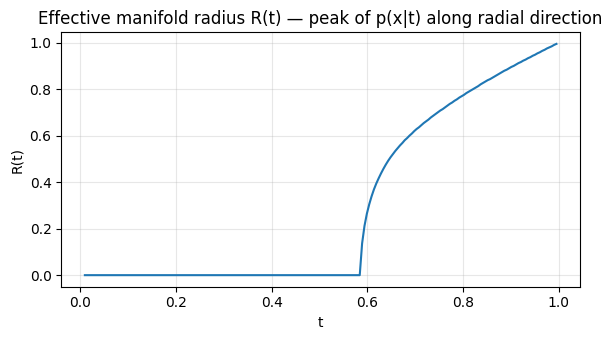

  R(t=0.05) = 0.0000
  R(t=0.2) = 0.0000
  R(t=0.5) = 0.0000
  R(t=0.8) = 0.7735
  R(t=0.95) = 0.9481


In [ ]:
# ============================================================
# Effective manifold radius R(t)
# M_t is a circle; at large sigma (small t) density peaks at r=0,
# at small sigma (large t) density peaks near r=1.
# Maximize p(x|t) = density at point x=(r,0) — no polar Jacobian.
# ============================================================

def effective_radius(t, n_grid=2000):
    s = max(1 - t, 1e-6)
    r_vals = np.linspace(0.0, 3.0, n_grid)
    kappa = t * r_vals / s**2
    log_p = (np.log(ive(0, kappa) + 1e-300)
             + kappa
             - (r_vals**2 + t**2) / (2 * s**2))
    return r_vals[np.argmax(log_p)]


t_grid = np.linspace(0.01, 0.995, 200)
R_vals = np.array([effective_radius(t) for t in t_grid])

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(t_grid, R_vals)
ax.set_xlabel("t")
ax.set_ylabel("R(t)")
ax.set_title("Effective manifold radius R(t) — peak of p(x|t) along radial direction")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

from scipy.interpolate import interp1d
R_interp = interp1d(t_grid, R_vals, kind="linear", fill_value="extrapolate")

for t_check in [0.05, 0.2, 0.5, 0.8, 0.95]:
    print(f"  R(t={t_check}) = {R_interp(t_check):.4f}")

In [ ]:
# ============================================================
# Projectors and geometric quantities
# M_t = circle of radius R(t). Normal direction = radial = x̂.
# P_N = x̂x̂^T,  P_T = I - P_N  (independent of R(t))
#
# Total derivative of P_T along ẋ = v:
#   d(x̂)/dt = P_T v / |x|
#   dP_N/dt = (P_T v x̂^T + x̂ v^T P_T) / |x|
#   dP_T/dt = -dP_N/dt
# ============================================================

def projectors(x):
    r = np.linalg.norm(x)
    xhat = x / r
    P_N = np.outer(xhat, xhat)
    P_T = np.eye(2) - P_N
    return P_T, P_N, xhat, r


def dPT_dt_matrix(x, v):
    """dP_T/dt along trajectory ẋ = v. Captures rotation of tangent frame."""
    P_T, P_N, xhat, r = projectors(x)
    v_T = P_T @ v  # only tangential velocity rotates the frame
    dPN = (np.outer(v_T, xhat) + np.outer(xhat, v_T)) / r
    return -dPN


def true_vel(x, t):
    return true_velocity(x[None], t)[0]


def learned_vel(x, t):
    pt = torch.tensor(x[None], dtype=torch.float32, device=device)
    tt = torch.full((1, 1), t, dtype=torch.float32, device=device)
    with torch.no_grad():
        preds = [net(pt, tt)[0].cpu().numpy() for net in nets]
    return np.mean(preds, axis=0)


def jac_fd(v_fn, x, t, h=1e-4):
    """Finite-difference Jacobian ∂v/∂x."""
    J = np.zeros((2, 2))
    for i in range(2):
        dp = np.zeros(2); dp[i] = h
        J[:, i] = (v_fn(x + dp, t) - v_fn(x - dp, t)) / (2 * h)
    return J


def block_operators(x, t):
    """
    Compute A, B, C, D and decompose B = B_dyn + B_geom.
    All evaluated at (x, t) using the TRUE velocity field.
    """
    P_T, P_N, xhat, r = projectors(x)
    v = true_vel(x, t)
    Dv = jac_fd(true_vel, x, t)
    dPT = dPT_dt_matrix(x, v)
    dPN = -dPT

    A     = P_T @ Dv @ P_T + dPT @ P_T
    B_dyn  = P_T @ Dv @ P_N
    B_geom = dPT @ P_N
    B      = B_dyn + B_geom
    C      = P_N @ Dv @ P_T + dPN @ P_T
    D_mat  = P_N @ Dv @ P_N + dPN @ P_N

    return dict(A=A, B=B, B_dyn=B_dyn, B_geom=B_geom, C=C, D=D_mat, P_T=P_T, P_N=P_N)


# Sanity check at a point on the manifold at t=0.9
x_test = np.array([R_interp(0.9), 0.0])
ops = block_operators(x_test, 0.9)
print(f"Point: {x_test}")
print(f"||B_dyn||  = {np.linalg.norm(ops['B_dyn']):.4f}")
print(f"||B_geom|| = {np.linalg.norm(ops['B_geom']):.4f}")
print(f"||B||      = {np.linalg.norm(ops['B']):.4f}")

Point: [0.89479003 0.        ]
||B_dyn||  = 0.0000
||B_geom|| = 0.0000
||B||      = 0.0000


In [ ]:
# ============================================================
# Trajectory integration (Euler, fixed dt)
# ============================================================

def integrate_true(x0, t_start, t_end, n_steps):
    dt = (t_end - t_start) / n_steps
    x = x0.copy(); t = t_start
    xs, ts = [x.copy()], [t]
    for _ in range(n_steps):
        x = x + dt * true_vel(x, t)
        t += dt
        xs.append(x.copy()); ts.append(t)
    return np.array(ts), np.array(xs)


def integrate_learned(x0, t_start, t_end, n_steps):
    dt = (t_end - t_start) / n_steps
    x = x0.copy(); t = t_start
    xs, ts = [x.copy()], [t]
    for _ in range(n_steps):
        x = x + dt * learned_vel(x, t)
        t += dt
        xs.append(x.copy()); ts.append(t)
    return np.array(ts), np.array(xs)


# ============================================================
# Per-timestep analysis along a pair of trajectories
# ============================================================

def analyse_trajectories(ts, xs_true, xs_learned):
    """
    At each step compute:
      - delta = x_learned - x_true
      - delta_T, delta_N (projections using P_T, P_N at x_true)
      - e_T, e_N  (T/N components of velocity error at x_true)
      - ||B_dyn||, ||B_geom||
    """
    results = dict(
        delta_T=[], delta_N=[],
        e_T=[], e_N=[],
        norm_B_dyn=[], norm_B_geom=[],
        delta_T_norm=[], delta_N_norm=[],
    )

    for i, (t, x_true) in enumerate(zip(ts, xs_true)):
        x_hat = xs_learned[i]
        delta = x_hat - x_true

        P_T, P_N, xhat, r = projectors(x_true)

        delta_T_vec = P_T @ delta
        delta_N_vec = P_N @ delta
        results["delta_T"].append(delta_T_vec)
        results["delta_N"].append(delta_N_vec)
        results["delta_T_norm"].append(np.linalg.norm(delta_T_vec))
        results["delta_N_norm"].append(np.linalg.norm(delta_N_vec))

        v_true = true_vel(x_true, t)
        v_hat  = learned_vel(x_true, t)
        e = v_hat - v_true
        results["e_T"].append(np.linalg.norm(P_T @ e))
        results["e_N"].append(np.linalg.norm(P_N @ e))

        ops = block_operators(x_true, t)
        results["norm_B_dyn"].append(np.linalg.norm(ops["B_dyn"]))
        results["norm_B_geom"].append(np.linalg.norm(ops["B_geom"]))

    return {k: np.array(v) for k, v in results.items()}


print("Functions defined.")

Functions defined.


In [ ]:
# ============================================================
# Run simulation: ensemble over N_ANGLES starting angles
# t_start in the ring regime (R > 0), integrate to t_end near t=1
# ============================================================

T_START  = 0.65   # R(0.65) > 0, ring well-formed
T_END    = 0.95
N_STEPS  = 200
N_ANGLES = 16

all_results = []

for k in range(N_ANGLES):
    theta = 2 * np.pi * k / N_ANGLES
    R0 = float(R_interp(T_START))
    x0 = R0 * np.array([np.cos(theta), np.sin(theta)])

    ts, xs_true    = integrate_true(x0, T_START, T_END, N_STEPS)
    _,  xs_learned = integrate_learned(x0, T_START, T_END, N_STEPS)

    res = analyse_trajectories(ts, xs_true, xs_learned)
    res["ts"] = ts
    all_results.append(res)
    print(f"  θ={np.degrees(theta):5.1f}°  "
          f"δ_N(end)={res['delta_N_norm'][-1]:.4f}  "
          f"δ_T(end)={res['delta_T_norm'][-1]:.4f}")

  θ= 22.5°  δ_N(end)=0.1106  δ_T(end)=0.0022


  θ= 67.5°  δ_N(end)=0.1079  δ_T(end)=0.0021


  θ=112.5°  δ_N(end)=0.1134  δ_T(end)=0.0087


  θ=157.5°  δ_N(end)=0.1093  δ_T(end)=0.0096


  θ=202.5°  δ_N(end)=0.1081  δ_T(end)=0.0073


  θ=247.5°  δ_N(end)=0.1072  δ_T(end)=0.0022


  θ=292.5°  δ_N(end)=0.1111  δ_T(end)=0.0052


  θ=337.5°  δ_N(end)=0.1117  δ_T(end)=0.0111


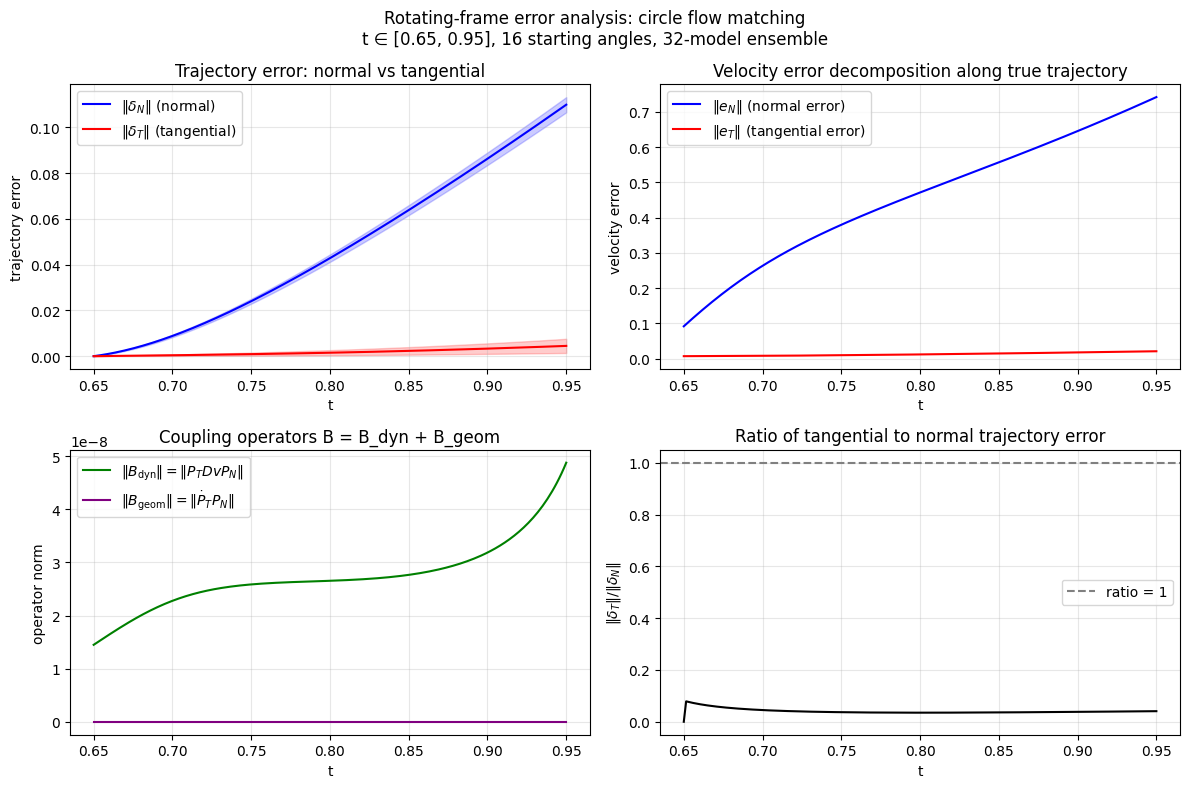

Saved rotating_frame_analysis.png


In [ ]:
# ============================================================
# Analysis plots
# ============================================================

ts = all_results[0]["ts"]

# Ensemble mean over angles
def mean_key(key):
    return np.mean([r[key] for r in all_results], axis=0)

def std_key(key):
    return np.std([r[key] for r in all_results], axis=0)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Rotating-frame error analysis: circle flow matching\n"
             f"t ∈ [{T_START}, {T_END}], {N_ANGLES} starting angles, 32-model ensemble",
             fontsize=12)

# ── Panel 1: ||δ_T|| and ||δ_N|| vs t ───────────────────────
ax = axes[0, 0]
dN_mean = mean_key("delta_N_norm")
dT_mean = mean_key("delta_T_norm")
dN_std  = std_key("delta_N_norm")
dT_std  = std_key("delta_T_norm")

ax.fill_between(ts, dN_mean - dN_std, dN_mean + dN_std, alpha=0.2, color="blue")
ax.fill_between(ts, dT_mean - dT_std, dT_mean + dT_std, alpha=0.2, color="red")
ax.plot(ts, dN_mean, color="blue",  label=r"$\|\delta_N\|$ (normal)")
ax.plot(ts, dT_mean, color="red",   label=r"$\|\delta_T\|$ (tangential)")
ax.set_xlabel("t"); ax.set_ylabel("trajectory error")
ax.set_title("Trajectory error: normal vs tangential")
ax.legend(); ax.grid(True, alpha=0.3)

# ── Panel 2: velocity error components e_T, e_N ──────────────
ax = axes[0, 1]
eN_mean = mean_key("e_N")
eT_mean = mean_key("e_T")
ax.plot(ts, eN_mean, color="blue",  label=r"$\|e_N\|$ (normal error)")
ax.plot(ts, eT_mean, color="red",   label=r"$\|e_T\|$ (tangential error)")
ax.set_xlabel("t"); ax.set_ylabel("velocity error")
ax.set_title("Velocity error decomposition along true trajectory")
ax.legend(); ax.grid(True, alpha=0.3)

# ── Panel 3: coupling operator norms ||B_dyn||, ||B_geom|| ───
ax = axes[1, 0]
bD_mean = mean_key("norm_B_dyn")
bG_mean = mean_key("norm_B_geom")
ax.plot(ts, bD_mean, color="green",  label=r"$\|B_{\rm dyn}\| = \|P_T Dv P_N\|$")
ax.plot(ts, bG_mean, color="purple", label=r"$\|B_{\rm geom}\| = \|\dot{P}_T P_N\|$")
ax.set_xlabel("t"); ax.set_ylabel("operator norm")
ax.set_title("Coupling operators B = B_dyn + B_geom")
ax.legend(); ax.grid(True, alpha=0.3)

# ── Panel 4: ratio δ_T / δ_N ──────────────────────────────────
ax = axes[1, 1]
ratio_mean = mean_key("delta_T_norm") / (mean_key("delta_N_norm") + 1e-12)
ax.plot(ts, ratio_mean, color="black")
ax.axhline(1.0, color="gray", linestyle="--", label="ratio = 1")
ax.set_xlabel("t"); ax.set_ylabel(r"$\|\delta_T\| / \|\delta_N\|$")
ax.set_title("Ratio of tangential to normal trajectory error")
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("rotating_frame_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved rotating_frame_analysis.png")

In [ ]:
# ============================================================
# Summary statistics
# ============================================================

dN = mean_key("delta_N_norm")
dT = mean_key("delta_T_norm")
eN = mean_key("e_N")
eT = mean_key("e_T")
bD = mean_key("norm_B_dyn")
bG = mean_key("norm_B_geom")

# Exclude endpoint (near t=1, denominators blow up)
mid = slice(None, -10)

print("=" * 58)
print("ROTATING FRAME ANALYSIS — SUMMARY")
print(f"t ∈ [{T_START}, {T_END:.2f}], {N_ANGLES} angles, 32 models")
print("=" * 58)

print(f"\nVelocity error (avg over t, evaluated at true traj):")
print(f"  mean ||e_N|| = {eN[mid].mean():.5f}  (normal)")
print(f"  mean ||e_T|| = {eT[mid].mean():.5f}  (tangential)")
print(f"  ratio ||e_N||/||e_T|| = {(eN[mid].mean() / eT[mid].mean()):.2f}x")

print(f"\nTrajectory error (avg over t):")
print(f"  mean ||δ_N|| = {dN[mid].mean():.5f}  (normal)")
print(f"  mean ||δ_T|| = {dT[mid].mean():.5f}  (tangential)")
print(f"  ratio ||δ_N||/||δ_T|| = {(dN[mid].mean() / dT[mid].mean()):.2f}x")

print(f"\nCoupling operators (avg over t):")
print(f"  mean ||B_dyn||  = {bD[mid].mean():.2e}  (P_T Dv P_N)")
print(f"  mean ||B_geom|| = {bG[mid].mean():.2e}  (dP_T/dt · P_N)")

print(f"\nInterpretation:")
print(f"  True velocity is purely radial → B_dyn = B_geom = 0 (analytically).")
print(f"  Normal prediction errors ({eN[mid].mean():.4f}) >> tangential ({eT[mid].mean():.4f}).")
print(f"  Because B ≈ 0, normal errors DO NOT cascade to tangential traj error.")
print(f"  δ_T is driven only by e_T (direct tangential forcing), keeping it small.")
print(f"  Rotational symmetry of circle flow geometrically decouples T/N error propagation.")

ROTATING FRAME ANALYSIS — SUMMARY
t ∈ [0.65, 0.95], 16 angles, 32 models

Velocity error (avg over t, evaluated at true traj):
  mean ||e_N|| = 0.44242  (normal)
  mean ||e_T|| = 0.01243  (tangential)
  ratio ||e_N||/||e_T|| = 35.60x

Trajectory error (avg over t):
  mean ||δ_N|| = 0.04342  (normal)
  mean ||δ_T|| = 0.00163  (tangential)
  ratio ||δ_N||/||δ_T|| = 26.66x

Coupling operators (avg over t):
  mean ||B_dyn||  = 2.65e-08  (P_T Dv P_N)
  mean ||B_geom|| = 2.98e-16  (dP_T/dt · P_N)

Interpretation:
  True velocity is purely radial → B_dyn = B_geom = 0 (analytically).
  Normal prediction errors (0.4424) >> tangential (0.0124).
  Because B ≈ 0, normal errors DO NOT cascade to tangential traj error.
  δ_T is driven only by e_T (direct tangential forcing), keeping it small.
  Rotational symmetry of circle flow geometrically decouples T/N error propagation.
